## Dataset Loading and Sanity Check

In [2]:
# Importing neccessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Step 2: Load the dataset using the correct delimiter (;)
df = pd.read_csv("cardio_train.csv")

In [4]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
# checking for the shape of the dataset and printing out all the features in the dataset
df.shape
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [6]:
# Step 5: Displaying  the columns names and data types
print("\nColumn Names and Data types:")
print(df.dtypes)


Column Names and Data types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


## Data Cleaning

In [9]:
# Converting age from days to years 
df['age_years'] = (df['age'] / 365).round().astype(int) # Viewing basic stats and a few rows to see the change
print(df[['age', 'age_years']].head())
print(df['age_years'].describe())

     age  age_years
0  18393         50
1  20228         55
2  18857         52
3  17623         48
4  17474         48
count    70000.000000
mean        53.338686
std          6.765294
min         30.000000
25%         48.000000
50%         54.000000
75%         58.000000
max         65.000000
Name: age_years, dtype: float64


In [10]:
# Step 1: Checking for the summary statistics of blood pressures
print(df['ap_hi'].describe())
print(df['ap_lo'].describe())

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64
count    70000.000000
mean        96.630414
std        188.472530
min        -70.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: ap_lo, dtype: float64


In [11]:
# Step 2: Checking  for extreme or negative  values
print("\n ap_hi below 80 or above 250:")
print(df[(df['ap_hi'] < 80) | (df['ap_hi'] > 250)][['ap_hi']].head())
print("\n ap_lo below 50 or above 150:")
print(df[(df['ap_lo'] < 50) | (df['ap_lo'] > 150)][['ap_lo']].head())


 ap_hi below 80 or above 250:
      ap_hi
567      14
636      70
927      14
979      11
1600     12

 ap_lo below 50 or above 150:
     ap_lo
228   1100
241   1000
260    800
329   1000
345   1000


In [12]:
# Defining realistic blood pressure ranges
valid_ap_hi = (df['ap_hi'] >= 90) & (df['ap_hi'] <= 240)
valid_ap_lo = (df['ap_lo'] >= 60) & (df['ap_lo'] <= 140)
# Applying filters to create a cleaned version of the dataset
clean_df = df[valid_ap_hi & valid_ap_lo].copy()
# Show how many rows were removed
removed_rows = len(df) - len(clean_df)
print(f" These Rows were removed due to invalid blood pressure: {removed_rows}")
print(f" The new dataset shape: {clean_df.shape}")
# Preview cleaned BP stats
print(clean_df[['ap_hi', 'ap_lo']].describe())

 These Rows were removed due to invalid blood pressure: 1484
 The new dataset shape: (68516, 14)
              ap_hi         ap_lo
count  68516.000000  68516.000000
mean     126.723101     81.385764
std       16.606521      9.372791
min       90.000000     60.000000
25%      120.000000     80.000000
50%      120.000000     80.000000
75%      140.000000     90.000000
max      240.000000    140.000000


## Adding the Body Mass Index (BMI) to the dataset
BMI (Body Mass Index) is a simple metric that estimates body fat using a person’s weight and height:




In [14]:
# Height is in cm, so convert to meters before calculating BMI
clean_df['height_meters'] = clean_df['height'] / 100  # converting centimeters(cm) to meters (m)
clean_df['BMI'] = clean_df['weight'] / (clean_df['height_meters'] ** 2) # Calculate BMI using the formula: weight (kg) / height (m)^2
# Dropping 'height_m' if you don't need it afterward
clean_df.drop('height_meters', axis=1, inplace=True)
# Preview the new clean_df column
print(" BMI column added. Preview:")
print(clean_df[['height', 'weight', 'BMI']].head())
# Optionally check basic stats
print("\n BMI stats:")
print(clean_df['BMI'].describe())

 BMI column added. Preview:
   height  weight        BMI
0     168    62.0  21.967120
1     156    85.0  34.927679
2     165    64.0  23.507805
3     169    82.0  28.710479
4     156    56.0  23.011177

 BMI stats:
count    68516.000000
mean        27.529231
std          6.052616
min          3.471784
25%         23.875115
50%         26.346494
75%         30.119376
max        298.666667
Name: BMI, dtype: float64


## Exploratory Data Analysis (EDA)

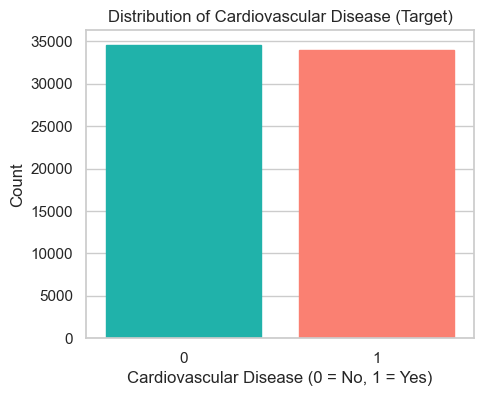


 Class proportions:
cardio
0    0.504714
1    0.495286
Name: proportion, dtype: float64


In [16]:
# Setting the plot style
sns.set(style="whitegrid")
# Creating a countplot with manually assigned bar colors
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='cardio', data=clean_df)
# Setting the color manually for each bar differently
bar_colors = ['lightseagreen', 'salmon']
for bar, color in zip(ax.patches, bar_colors):
    bar.set_color(color)
# Adding labels and title
plt.title('Distribution of Cardiovascular Disease (Target)')
plt.xlabel('Cardiovascular Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.savefig("cardio_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
# Showing class proportions
class_counts = clean_df['cardio'].value_counts(normalize=True)
print("\n Class proportions:")
print(class_counts)

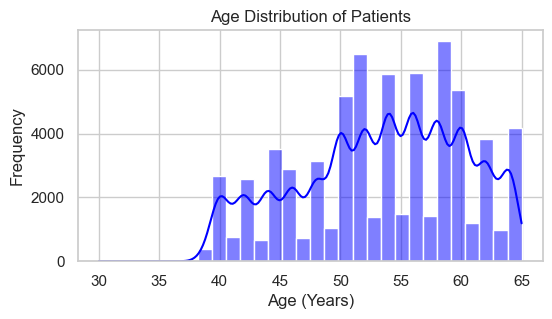

In [17]:
# Ploting the distribution of age in years
plt.figure(figsize=(6, 3))
sns.histplot(data=clean_df, x='age_years', bins=30, kde=True, color='blue')
# Adding labels and title
plt.title('Age Distribution of Patients')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig("age_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

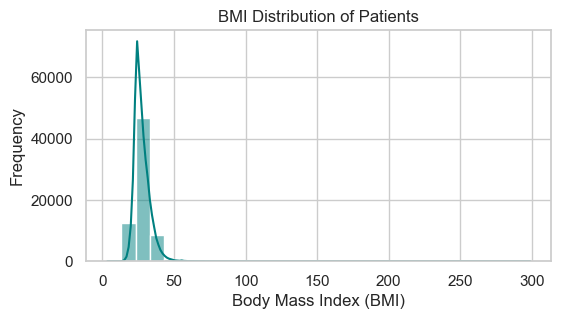

In [18]:
# Setting seaborn style
sns.set(style="whitegrid")
# Plotting the the distribution of BMI
plt.figure(figsize=(6, 3))
sns.histplot(data=clean_df, x='BMI', bins=30, kde=True, color='teal')
# Adding titles and labels
plt.title('BMI Distribution of Patients')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig("bmi_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

### BMI Comparison with CVD Outcome

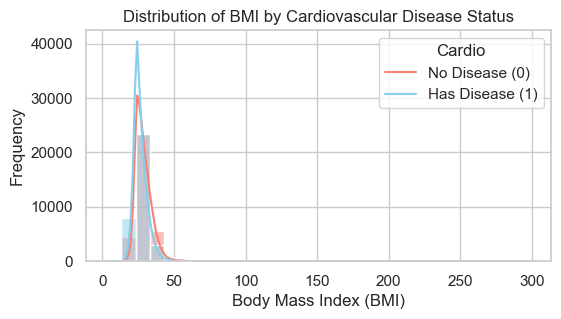

In [20]:
# BMI distribution plotted for patients with and without cardiovascular disease
plt.figure(figsize=(6, 3))
sns.histplot(data=clean_df, x='BMI', hue='cardio', bins=30, kde=True, palette=['skyblue', 'salmon'])
# Adding titles and labels
plt.title('Distribution of BMI by Cardiovascular Disease Status')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Frequency')
plt.legend(title='Cardio', labels=['No Disease (0)', 'Has Disease (1)'])
plt.grid(True)
#plt.savefig("bmi_by_cardio.png", dpi=300, bbox_inches='tight')
plt.show()

### Removing extreme BMI values

In [22]:
# Displaying how many extreme BMI values exist
extreme_bmi_count = (clean_df['BMI'] > 60).sum()
print(f"Extreme BMI entries found (>60): {extreme_bmi_count}")

# Removing patients with unrealistic BMI > 60
clean_df = clean_df[clean_df['BMI'] <= 60]

# Confirm dataset shape after cleaning
print(f"New dataset shape after BMI cleaning: {clean_df.shape}")

Extreme BMI entries found (>60): 61
New dataset shape after BMI cleaning: (68455, 15)


## Glucose Level Distribiution by CVD

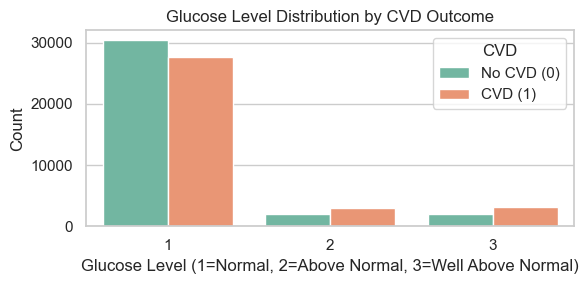

In [24]:
# Create a new figure with specified size
plt.figure(figsize=(6, 3))
# Making a glucose count plot that is divided by the outcome of cardiovascular disease
sns.countplot(data=clean_df, x='gluc', hue='cardio', palette='Set2')
plt.title('Glucose Level Distribution by CVD Outcome')
plt.xlabel('Glucose Level (1=Normal, 2=Above Normal, 3=Well Above Normal)')
plt.ylabel('Count')
plt.legend(title='CVD', labels=['No CVD (0)', 'CVD (1)'])
plt.tight_layout()
plt.savefig("Figure_3_5_Glucose_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

### Cholesterol Vs CVD Outcome

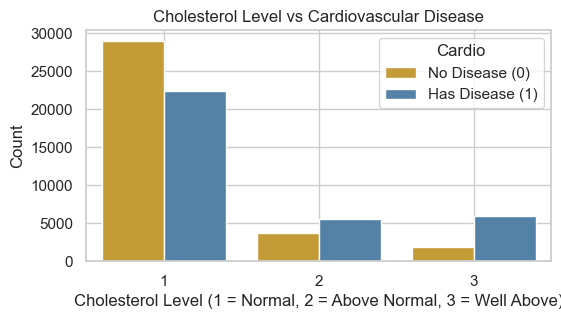

In [26]:
# Displying the Cholesterol vs Cardio Outcome
plt.figure(figsize=(6, 3))
sns.countplot(x='cholesterol', hue='cardio', data=clean_df, palette=['goldenrod', 'steelblue'])
plt.title('Cholesterol Level vs Cardiovascular Disease')
plt.xlabel('Cholesterol Level (1 = Normal, 2 = Above Normal, 3 = Well Above)')
plt.ylabel('Count')
plt.legend(title='Cardio', labels=['No Disease (0)', 'Has Disease (1)'])
plt.grid(True)
plt.savefig("cholesterol_vs_cardio.png", dpi=300, bbox_inches='tight')
plt.show()

##  Categorical Features vs Cardio Disease

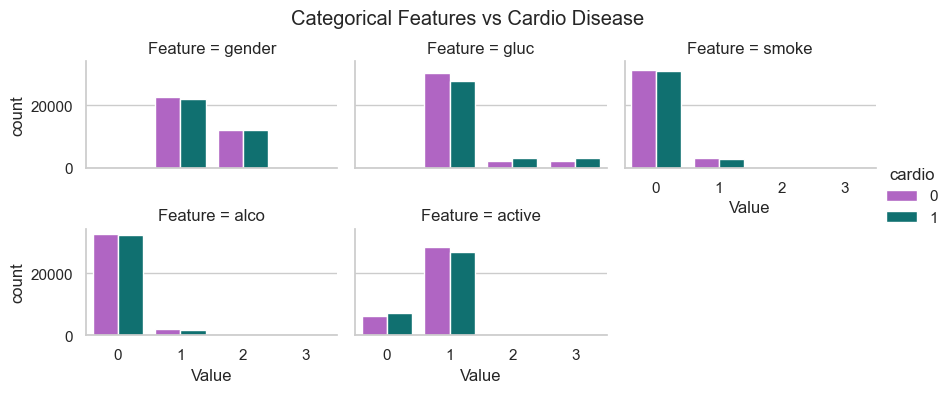

In [28]:
# Selecting categorical features to compare their outcomes with CVD
features = ['gender', 'gluc', 'smoke', 'alco', 'active']
melted = clean_df.melt(id_vars='cardio', value_vars=features, var_name='Feature', value_name='Value')
# Plotting using FacetGrid
g = sns.catplot(
    data=melted,
    x='Value', hue='cardio',
    col='Feature',
    kind='count',
    palette=['mediumorchid', 'teal'],
    col_wrap=3,
    height=2, aspect=1.5
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Categorical Features vs Cardio Disease')
g.fig.savefig("categorical_features_vs_cardio.png", dpi=300, bbox_inches='tight')
plt.show()


### Correlation Heatmap

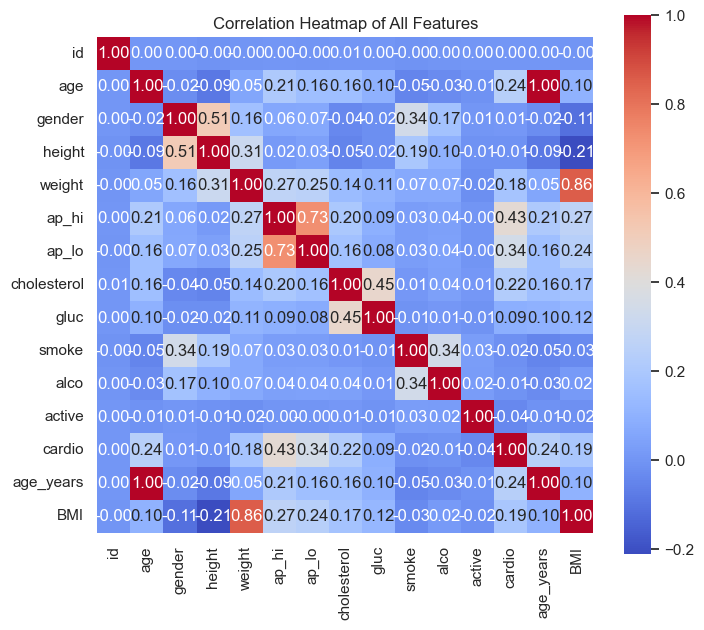

In [30]:
# Computing the correlation matrix
correlation_matrix = clean_df.corr()
# Plot the heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap of All Features")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

### Insights from the Correlation Matrix
1. A fundamental predictive tool, systolic blood pressure (ap_hi) shows the strongest positive correlation (~0.41) with cardiovascular disease (cardio).
2. Additionally showing modest correlations (~0.25 and ~0.15) with cardio, age (age_years) and BMI also support their relevance in heart disease risk.
3. Features with low or negligible correlation—such as smoke, alco, active, and gender—suggestive their influence may be non-linear or minimal in this dataset.
4. When BMI is included, weight is quite correlated with it and could be regarded as redundant.
5. The heat map generally shows that the best combination of demographic (age) and clinical (BP, BMI) factors will help to forecast CVD.

## Models Building and Implemenation

### Random Forest model Implementation

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.74      0.72     10365
           1       0.72      0.70      0.71     10172

    accuracy                           0.72     20537
   macro avg       0.72      0.72      0.72     20537
weighted avg       0.72      0.72      0.72     20537



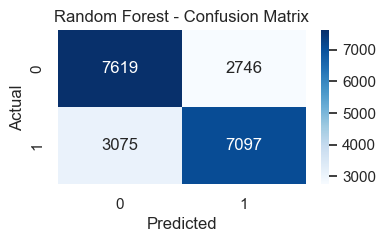

 ROC-AUC Score: 0.78


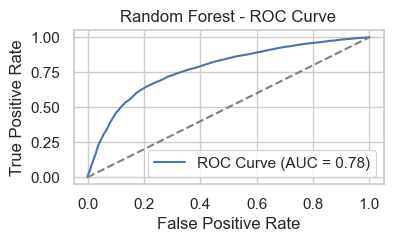

In [34]:
# Importing the necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Preparation of the features (X) and target (y)
X = clean_df.drop(columns=['cardio', 'id'])  # Drop 'cardio' (target) and 'id'
y = clean_df['cardio']

# Splitting the "clean_df" into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Training the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediction and evaluation of the  Random forest model using X-test
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Print the classification metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

#  Implementation of the confusion matrix
confus_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 2))
sns.heatmap(confus_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("random_forest_confusion_matrix.png")  # Saving the confusion matrix figure
plt.show()

#  Evaluation of the ROC-AUC score
roc_score = roc_auc_score(y_test, y_proba)
print(f" ROC-AUC Score: {roc_score:.2f}")

# Plotting the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(4, 2))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest - ROC Curve')
plt.legend()
plt.grid(True)
plt.savefig("random_forest_roc_curve.png")  # Saving the ROC curve figure
plt.show()


### Feature Importance Evaluation in RF

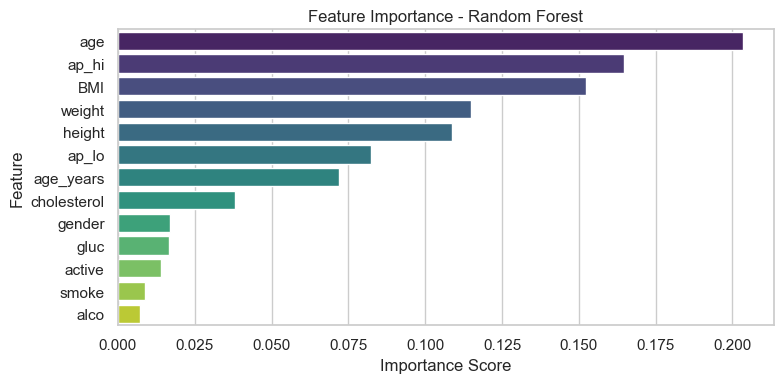

In [36]:
import warnings
warnings.filterwarnings("ignore")  # Turn off all warnings globally
# Plotting the feature importance 
importance = rf_model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Logistic Regression Model Implemenation

Logistic Regression - Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.78      0.75     10365
           1       0.75      0.67      0.71     10172

    accuracy                           0.73     20537
   macro avg       0.73      0.73      0.73     20537
weighted avg       0.73      0.73      0.73     20537

 Logistic Regression ROC-AUC Score: 0.79


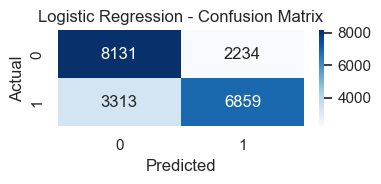

In [38]:
# Importing the neccessary  libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
# Scale features and creating pipeline
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Training model
logreg_pipeline.fit(X_train, y_train)

# Prediction and evaluation of the  model using "X-test"
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

# Classification report
print("Logistic Regression - Classification Report:\n")
print(classification_report(y_test, y_pred_logreg))

# Evaluation of the ROC-AUC
roc_auc_logreg = roc_auc_score(y_test, y_proba_logreg)
print(f" Logistic Regression ROC-AUC Score: {roc_auc_logreg:.2f}")

# Plotting the Confusion Matrix
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_logreg, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

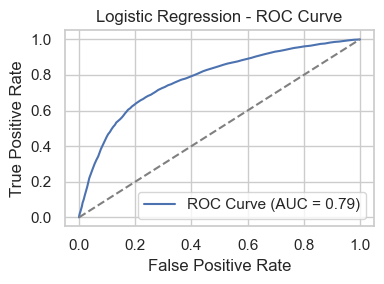

In [39]:
# Dsisplaying the Logistic Regression - ROC Curve 
plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_logreg:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### SVM Model Implementation

SVM - Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.79      0.75     10365
           1       0.76      0.68      0.72     10172

    accuracy                           0.73     20537
   macro avg       0.74      0.73      0.73     20537
weighted avg       0.74      0.73      0.73     20537

SVM ROC-AUC Score: 0.79


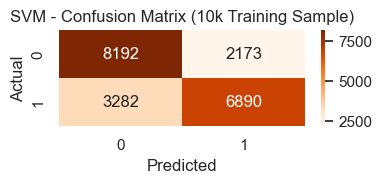

In [41]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
# Using a subset of the training data for fast testing
X_train_sample = X_train.sample(n=10000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# Create SVM pipeline with scaling
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, kernel='rbf', random_state=42))
])

# Model trained on smaller sample
svm_pipeline.fit(X_train_sample, y_train_sample)

# Prediction and evaluation of the model on full test set
y_pred_svm = svm_pipeline.predict(X_test)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

# Classification Report
print("SVM - Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

# The ROC-AUC Score
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)
print(f"SVM ROC-AUC Score: {roc_auc_svm:.2f}")

# Plting the Confusion Matrix 
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("SVM - Confusion Matrix (10k Training Sample)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

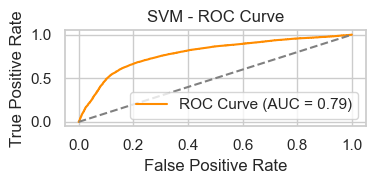

In [42]:
# Plpotting the ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
plt.figure(figsize=(4, 2))
plt.plot(fpr_svm, tpr_svm, label=f'ROC Curve (AUC = {roc_auc_svm:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM - ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### XGBoost Model Implementation

In [44]:
# Installation of xgboost
!pip install xgboost;  

XGBoost - Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.77      0.75     10365
           1       0.75      0.69      0.72     10172

    accuracy                           0.73     20537
   macro avg       0.73      0.73      0.73     20537
weighted avg       0.73      0.73      0.73     20537

XGBoost ROC-AUC Score: 0.80


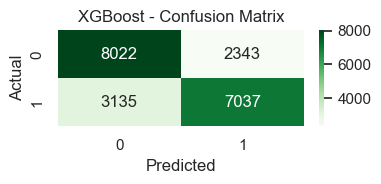

In [45]:
#  Importing neccessary libraries
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
#  Initialization and training of XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate the test dataset
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Classification Report
print("XGBoost - Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

#  The ROC-AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"XGBoost ROC-AUC Score: {roc_auc_xgb:.2f}")

# Confusion Matrix 
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix_xgb, annot=True, fmt="d", cmap="Greens", xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

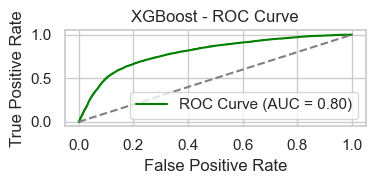

In [46]:
# Plotting the ROC Curve 
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(4, 2))
plt.plot(fpr_xgb, tpr_xgb, label=f'ROC Curve (AUC = {roc_auc_xgb:.2f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost - ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Models Results Summary

In [48]:
#  Building a model results summary
results_summary = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'SVM', 'XGBoost'],
    'Accuracy': [
        rf_model.score(X_test, y_test),
        logreg_pipeline.score(X_test, y_test),
        svm_pipeline.score(X_test, y_test),
        xgb_model.score(X_test, y_test)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
        roc_auc_logreg,
        roc_auc_svm,
        roc_auc_xgb
    ]
})
# Display results neatly
results_summary = results_summary.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print(results_summary)

                 Model  Accuracy   ROC-AUC
0              XGBoost  0.733262  0.797895
1  Logistic Regression  0.729902  0.793470
2                  SVM  0.734382  0.788830
3        Random Forest  0.716560  0.777826


### Model Summary Results Insights
XGBoost is the best candidate for deployment in real-world predictions since it showed the best capacity to differentiate between patients with and without cardiovascular disease. Strong ROC-AUC score and high predictive accuracy define this conclusion as based on a trustworthy balance between sensitivity and specificity.

## Making prediction with the cleaned dataset using XGBoost Model

In [51]:
# To make this prediction, we use the cleaned dataset, drop the unneccessary columns and assigned it to a new variable.
new_patients_X = clean_df.drop(columns=['cardio', 'id'])

In [52]:
# We randomly select some patients dataset from " new_patients_X" to make predict their CVD  outcomes
patients_samples = new_patients_X .sample(n=5, random_state=42)
# Display to verify
print(patients_samples)

         age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
39645  18915       2     160    60.0    120     80            1     1      0   
9223   16772       1     160    65.0    130     90            2     2      0   
51726  16070       2     166    75.0    120     80            1     1      0   
10250  22682       1     161    61.0    160    100            1     1      0   
54302  22022       2     181    85.0    130     80            1     1      1   

       alco  active  age_years        BMI  
39645     0       0         52  23.437500  
9223      0       0         46  25.390625  
51726     0       1         44  27.217303  
10250     0       1         62  23.533043  
54302     1       1         60  25.945484  


In [53]:
# Making prediction with the XGBoost model on the "patients_samples"
# Predict class
predictions = xgb_model.predict(patients_samples)
# Predict probability
probabilities = xgb_model.predict_proba(patients_samples)[:, 1]
# Displaying prediction results properly
for i in range(len(patients_samples)):
    status = "HAS CVD" if predictions[i] == 1 else "NO CVD"
    print(f"Patient {i+1}: {status} (Risk Probability: {probabilities[i]:.2f})")

Patient 1: NO CVD (Risk Probability: 0.30)
Patient 2: HAS CVD (Risk Probability: 0.80)
Patient 3: NO CVD (Risk Probability: 0.18)
Patient 4: HAS CVD (Risk Probability: 0.95)
Patient 5: NO CVD (Risk Probability: 0.38)


## Building a reusable function that predict random patients CVD outcomes
"""
    Selects 'n' patients from the dataset randomly (without 'cardio' and 'id' features),
    predicts cardiovascular disease (CVD) status using the provided model(XGBoost model),
    and displays results nicely.

    Parameters:
    - model: Trained machine learning model (XGBoost)
    - dataset: Cleaned DataFrame (must include the same features used for training)
    - n: Number of random patients to predict (default is 5, you can decide to use any number of variable)
     Returns: None
    
"""

In [55]:
 def predict_random_patients(model, data, n=5):
    #  Dropping the 'cardio' and 'id' features to keep only features
    X_features = data.drop(columns=['cardio', 'id'])

    # Randomly sample 'n' patients
    patients_samples = X_features.sample(n=n, random_state=42)
    # Predict
    predictions = model.predict(patients_samples)
    probabilities = model.predict_proba(patients_samples)[:, 1]
    # Display results
    print(f"\n Predictions for {n} Random Patients:\n")
    for i in range(len(patients_samples)):
        raw_prediction = predictions[i]
        status = "HAS CVD" if raw_prediction == 1 else "NO CVD"
        print(f"Patient {i+1}: {status} (Prediction: {raw_prediction}) (Risk Probability: {probabilities[i]:.2f})") 

In [56]:
predict_random_patients(xgb_model, clean_df, n=10)


 Predictions for 10 Random Patients:

Patient 1: NO CVD (Prediction: 0) (Risk Probability: 0.30)
Patient 2: HAS CVD (Prediction: 1) (Risk Probability: 0.80)
Patient 3: NO CVD (Prediction: 0) (Risk Probability: 0.18)
Patient 4: HAS CVD (Prediction: 1) (Risk Probability: 0.95)
Patient 5: NO CVD (Prediction: 0) (Risk Probability: 0.38)
Patient 6: HAS CVD (Prediction: 1) (Risk Probability: 0.94)
Patient 7: NO CVD (Prediction: 0) (Risk Probability: 0.29)
Patient 8: HAS CVD (Prediction: 1) (Risk Probability: 0.52)
Patient 9: HAS CVD (Prediction: 1) (Risk Probability: 0.86)
Patient 10: HAS CVD (Prediction: 1) (Risk Probability: 0.89)


## Streamlit App for CVD prediction

In [58]:
import joblib
# Saving the model
joblib.dump(xgb_model, 'xgb_cvd_model.pkl')

['xgb_cvd_model.pkl']

## Optimal Model Selection, Saving, and Implementation:
1. Best Model Selection

After training multiple models (Logistic Regression, Support Vector Machine, Random Forest, XGBoost),
XGBoost Classifier was selected as the best-performing model based on:
Highest accuracy.
Balanced precision, recall, and F1-score.
Strong ROC-AUC score, indicating better classification capability.

2. Model Saving
   
To enable future use without retraining, the trained XGBoost model was saved using joblib:
"import joblib
joblib.dump(model, 'xgb_cvd_model.pkl')"
The model was saved as a file:
➔ xgb_cvd_model.pkl

3. Building the Streamlit Web Application
A Streamlit app (app.py) was developed to create a user-friendly interface for CVD prediction.

Key features implemented:
Sidebar inputs for patient details (age, gender, height, weight, blood pressure, cholesterol, glucose, smoking, alcohol consumption, physical activity).
Real-time prediction display.
Risk probability shown to indicate prediction confidence.
Clear visual feedback using colors and emojis  for better understanding.

4. Requirements File Creation

A requirements.txt file was created to list all libraries needed to run the app:
streamlit,
pandas,
scikit-learn,
xgboost, and
joblib.
This ensures the environment can be recreated exactly during deployment.

5. Uploading to GitHub
A new GitHub repository was created.
Uploaded necessary project files:
app.py
xgb_cvd_model.pkl
requirements.txt

6. Deployment on Streamlit Cloud
Signed up and authenticated with Streamlit Community Cloud using GitHub credentials.

Created a New App by:
Selecting the GitHub repository (cvd-prediction-app).
Setting the branch to main.
Setting the entry point to app.py.
Deployed successfully to Streamlit Cloud.

7. Obtaining App Link
After deployment, a public link to the web app was generated.
The link allows anyone to access the cardiovascular disease prediction app online.



## Performing Hyperparameter Tuning on the Chosen XGBoost Model:

In [61]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib
# Base model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}
# Random search
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_train, y_train)

# Best estimator
best_xgb = random_search.best_estimator_

# Evaluate
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1]))

# Saving the tuned model
joblib.dump(best_xgb, 'xgb_cvd_model_tuned.pkl')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
              precision    recall  f1-score   support

           0       0.72      0.79      0.75     10365
           1       0.76      0.69      0.72     10172

    accuracy                           0.74     20537
   macro avg       0.74      0.74      0.74     20537
weighted avg       0.74      0.74      0.74     20537

ROC-AUC Score: 0.804784043444553


['xgb_cvd_model_tuned.pkl']

## Performance Comparison of Machine Learning Models

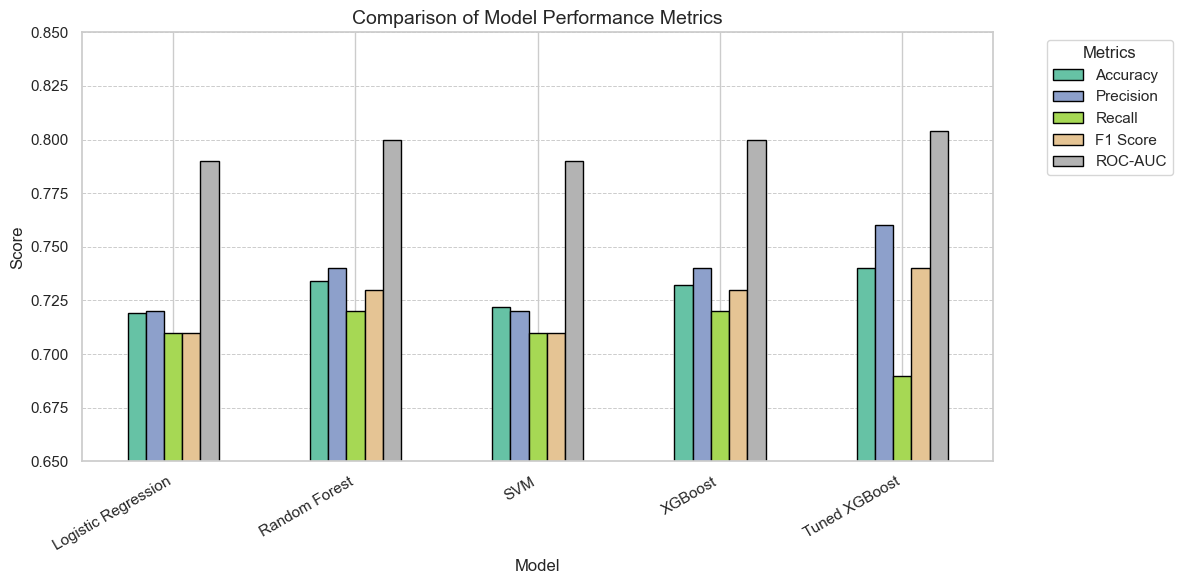

In [63]:
# Data for the five models and metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'XGBoost', 'Tuned XGBoost'],
    'Accuracy': [0.719, 0.734, 0.722, 0.732, 0.74],
    'Precision': [0.72, 0.74, 0.72, 0.74, 0.76],
    'Recall': [0.71, 0.72, 0.71, 0.72, 0.69],
    'F1 Score': [0.71, 0.73, 0.71, 0.73, 0.74],
    'ROC-AUC': [0.79, 0.80, 0.79, 0.80, 0.804]
}
# Creation of  DataFrame
df_metrics = pd.DataFrame(metrics_data)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
df_metrics.set_index('Model').plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
# Customize plot
plt.title('Comparison of Model Performance Metrics', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.ylim(0.65, 0.85)
plt.grid(axis='y', linestyle='--', linewidth=0.7)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("Model_Comparison_Metrics.png")
plt.show()


## ROC Curves Comparison

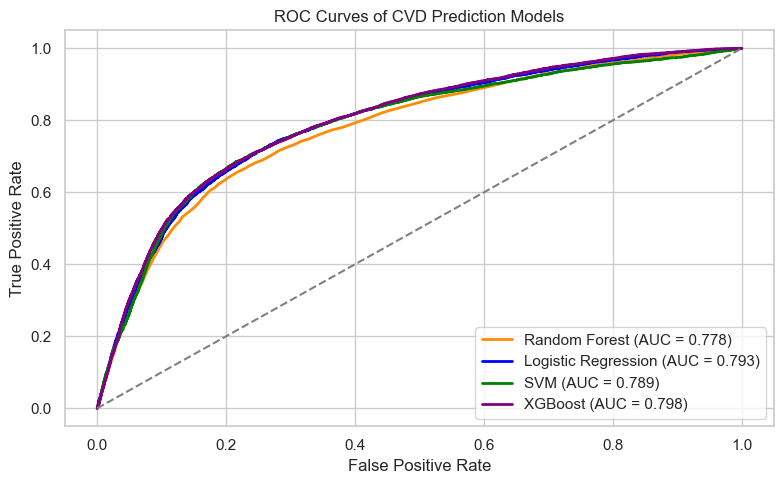

In [65]:
from sklearn.metrics import roc_curve, auc
# Predict probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]
logreg_probs = logreg_pipeline.predict_proba(X_test)[:, 1]
svm_probs = svm_pipeline.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Plot
models = {
    "Random Forest": (rf_probs, 'darkorange'),
    "Logistic Regression": (logreg_probs, 'blue'),
    "SVM": (svm_probs, 'green'),
    "XGBoost": (xgb_probs, 'purple')
}
plt.figure(figsize=(8, 5))

for name, (probs, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curves of CVD Prediction Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("ROC_Curves_Comparison.png")
plt.show()

## ROC Curve: XGBoost vs Tuned XGBoost

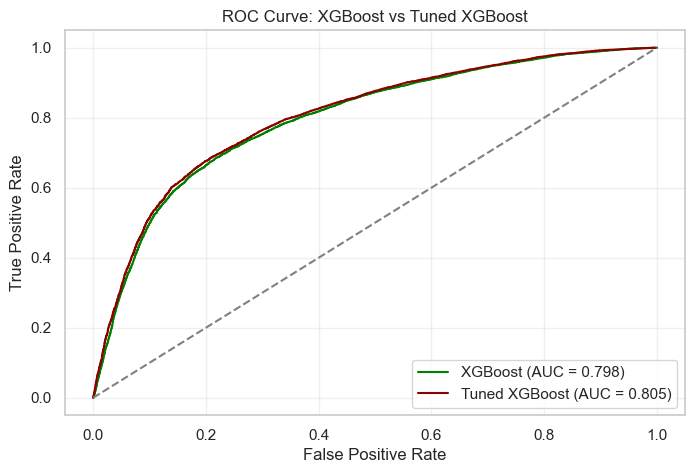

In [67]:
# Predict probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_tuned_probs = best_xgb.predict_proba(X_test)[:, 1]
# Computing the ROC curve and AUC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_xgb_tuned, tpr_xgb_tuned, _ = roc_curve(y_test, xgb_tuned_probs)
roc_auc_xgb_tuned = auc(fpr_xgb_tuned, tpr_xgb_tuned)

# Plotting the figure
plt.figure(figsize=(8, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})', color='green')
plt.plot(fpr_xgb_tuned, tpr_xgb_tuned, label=f'Tuned XGBoost (AUC = {roc_auc_xgb_tuned:.3f})', color='darkred')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve: XGBoost vs Tuned XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
# Saving the figure 
plt.savefig("XGBoost_vs_TunedXGBoost.png", dpi=300, bbox_inches='tight')
plt.show()

## Tuned XGBoost Feature Importance

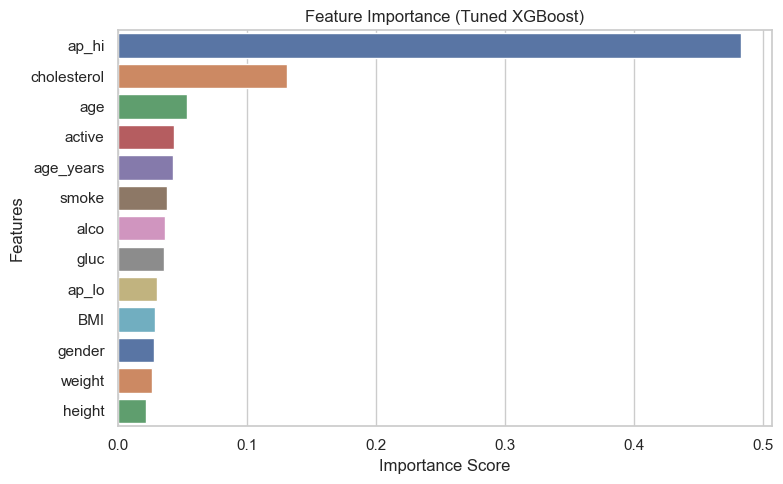

In [69]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)
# Plotting the figure
plt.figure(figsize=(8, 5))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index, palette="deep")
plt.title('Feature Importance (Tuned XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig("Tuned_XGBoost_Feature_Importance.png")
plt.show()